# Imports + setup

In [1]:
import os
import random
import json
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import importlib, inspect, types

from collections import defaultdict
from transformers import AutoModelForSequenceClassification, AutoTokenizer

import lrp_cp_transformer as lrp

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from transformers import RobertaTokenizer, AutoModelForSequenceClassification

# FIX: The lrp module requires an EPS value for numerical stability.
# We define it here and assign it to the imported module's namespace.
lrp.EPS = 1e-8

C:\Projects\BUAS\Y2\block-a\fae2-nlpr-group-group-9-1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# settings
MODEL_PATH = "./roberta_emotion_model"
CSV_PATH   = "../data/kinga.csv"
TEXT_COL   = "Translation"
LABEL_COL  = "Emotion_core"
N_PER_LABEL = 3
OUT_DIR    = "explanations_task_10_part_2"
SEED       = 42

# Create output directory
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "gxi"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "lrp"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "mr"), exist_ok=True)

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

In [4]:
try:
    # FIX: Added attn_implementation='eager' to resolve the warning.
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, attn_implementation="eager")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model.to(DEVICE)
    print("Model and tokenizer loaded successfully.")
    print(f"Tokenizer class: {tokenizer.__class__.__name__}")
except Exception as e:
    print(f"Error loading model/tokenizer: {e}")
    print("Please ensure the MODEL_PATH is correct and points to a saved model directory.")
    exit()

Model and tokenizer loaded successfully.
Tokenizer class: RobertaTokenizerFast


In [5]:
emotions = ['disgust','fear','happiness','anger','sadness','surprise','neutral']
label2id = {lbl: i for i, lbl in enumerate(emotions)}
id2label = {i: lbl for lbl, i in label2id.items()}

In [6]:
label2id

{'disgust': 0,
 'fear': 1,
 'happiness': 2,
 'anger': 3,
 'sadness': 4,
 'surprise': 5,
 'neutral': 6}

# Random sentences from our dataset

In [7]:
# Load dataset 
df = pd.read_csv(CSV_PATH)

# Ensure class balance
emotions = df[LABEL_COL].unique()
print("Emotion classes:", emotions)

# Select 3 random sentences per emotion
examples_by_emotion = defaultdict(list)
for emotion in emotions:
    subset = df[df[LABEL_COL] == emotion]["Translation"].dropna().tolist()
    random.shuffle(subset)
    examples_by_emotion[emotion] = subset[:3]


Emotion classes: ['neutral' 'surprise' 'happiness' 'anger' 'fear' 'sadness' 'disgust']


In [8]:
examples_by_emotion

defaultdict(list,
            {'neutral': ['Music',
              "I know what a jalapeno looks like. It's a short, red pepper, like a small tomato.",
              'Karambola.'],
             'surprise': ['Are you ready? Reds?',
              'Three minutes to the end, three minutes.',
              'Shock, right?'],
             'happiness': ['I am a dinosaur who wants to fight, who will not give up.',
              'Here you go, strawberry.',
              'How nice, seconds, yes!'],
             'anger': ['No, no, no.',
              'Then start.',
              'Why not put all this responsibility on him?'],
             'fear': ["It's not good, there are a lot of them.",
              'As I stood, I said, is that enough?',
              "They have to be in the oven, because otherwise you won't make it in time."],
             'sadness': ['Why did we lose?',
              'how difficult all this is.',
              "but you can't try them."],
             'disgust': ['because taki

## Part 1

In [9]:
def gradient_x_input(model, inputs):
    inputs_embeds = model.get_input_embeddings()(inputs.input_ids)
    inputs_embeds = inputs_embeds.clone().detach().requires_grad_(True)
    outputs = model(inputs_embeds=inputs_embeds, attention_mask=inputs.attention_mask)
    outputs.logits[:, outputs.logits.argmax()].backward()
    # Fix for NoneType issue — return zero tensor if grad is None
    if inputs_embeds.grad is None:
        raise RuntimeError("Gradients are not computed! Make sure inputs_embeds is correctly passed through the model.")

    return inputs_embeds.grad * inputs_embeds

In [10]:
# Prepare text data from examples_by_emotion for GxI visualization
text_list = []
for emotion in emotions:
    if emotion in examples_by_emotion:
        text_list.extend(examples_by_emotion[emotion])

text = text_list[:21]  # Use first 21 examples (3 per emotion for 7 emotions)
print(f"Using {len(text)} examples for GxI visualization")

Using 21 examples for GxI visualization


In [11]:
# Tokenize inputs
inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
print(f"Input shape: {inputs['input_ids'].shape}")

Input shape: torch.Size([21, 26])


In [12]:
# Get model predictions
model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    predicted_emotion = outputs.logits.argmax(dim=-1).tolist()

# Create model_label_to_emotion mapping
model_label_to_emotion = id2label
print(f"Predicted emotions for {len(predicted_emotion)} examples")

Predicted emotions for 21 examples


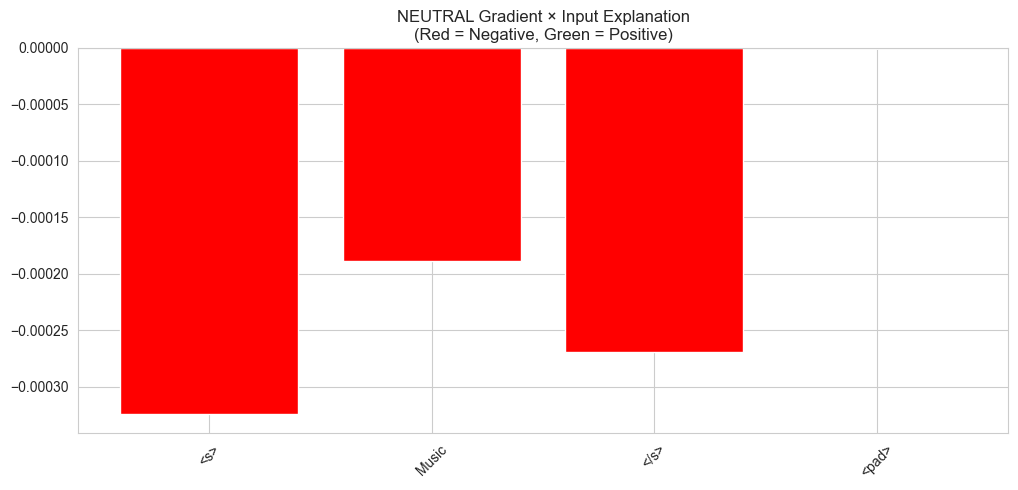

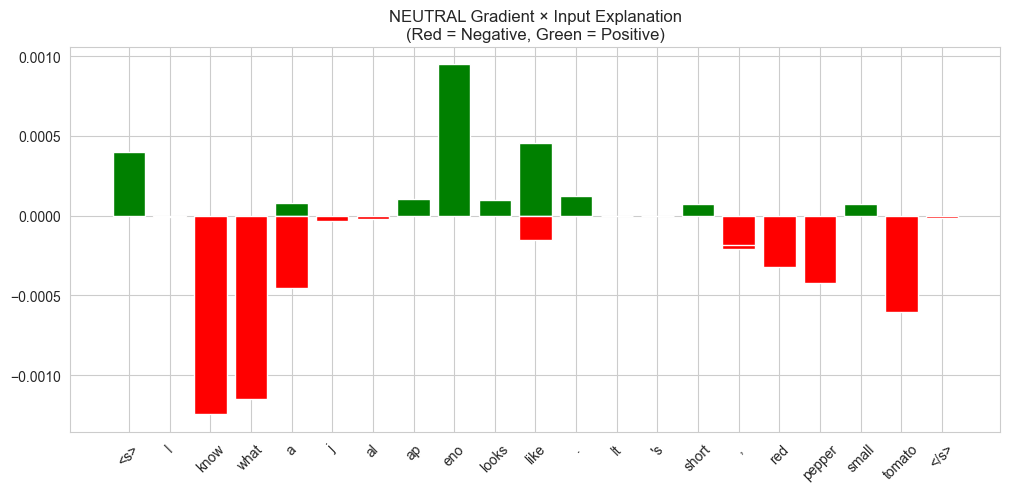

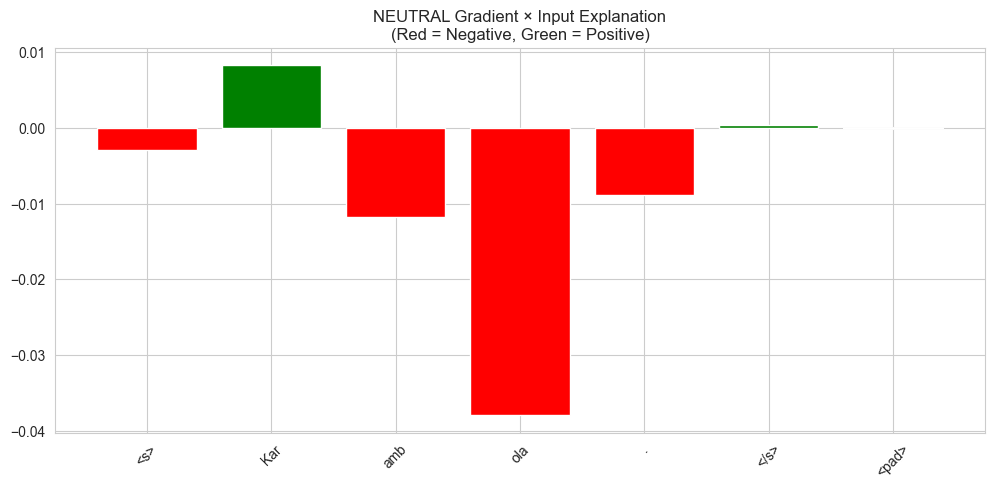

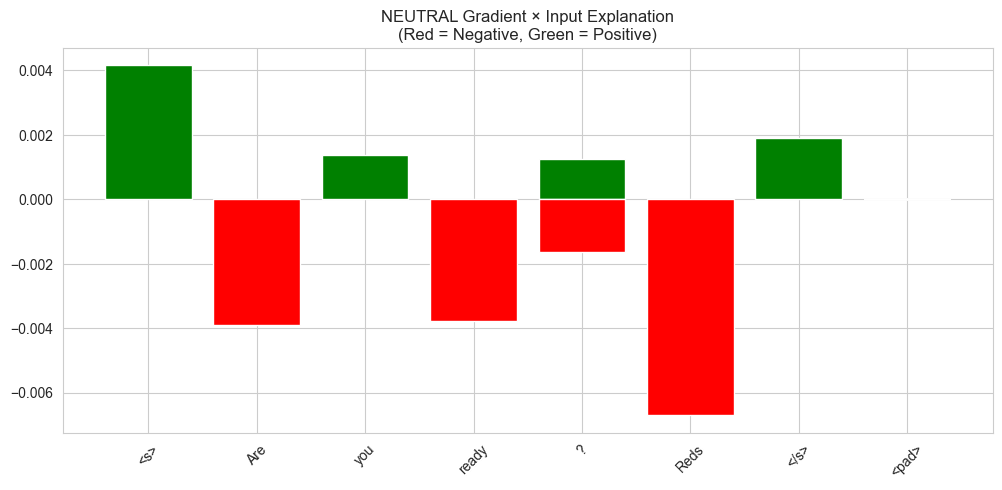

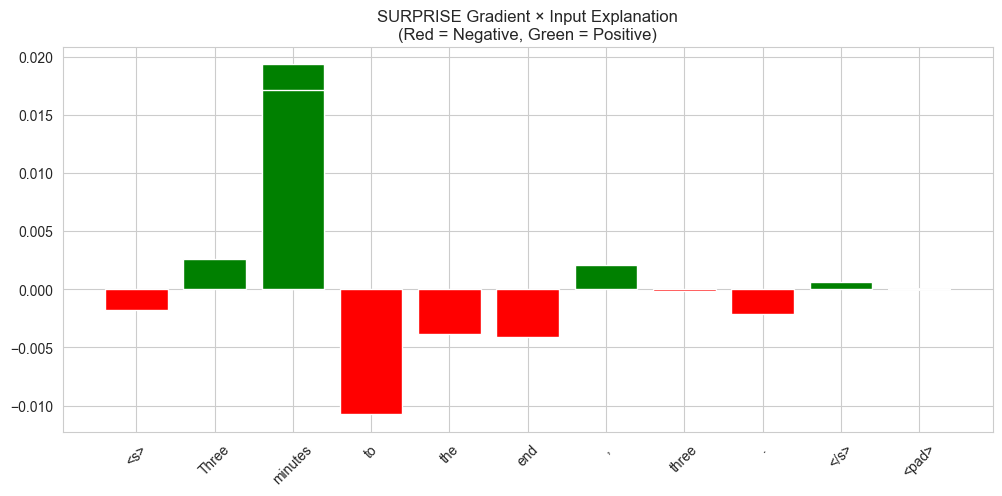

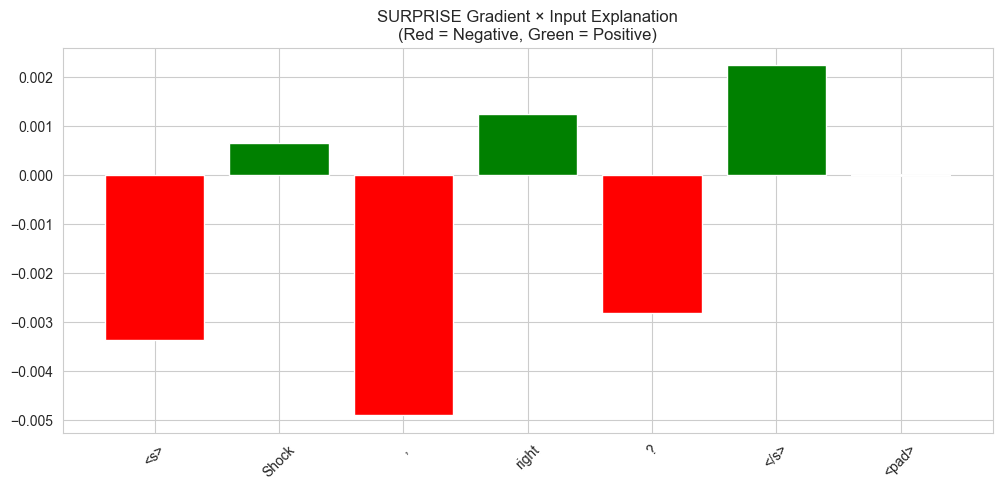

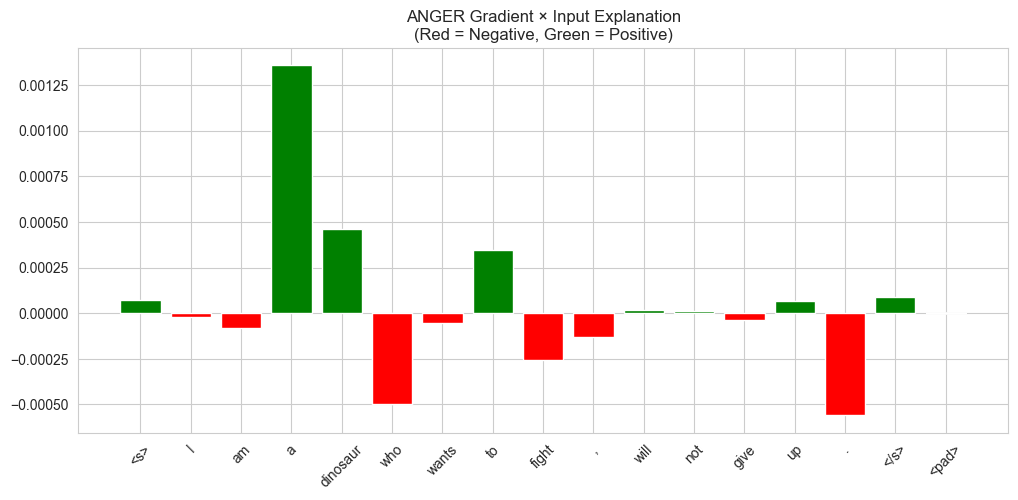

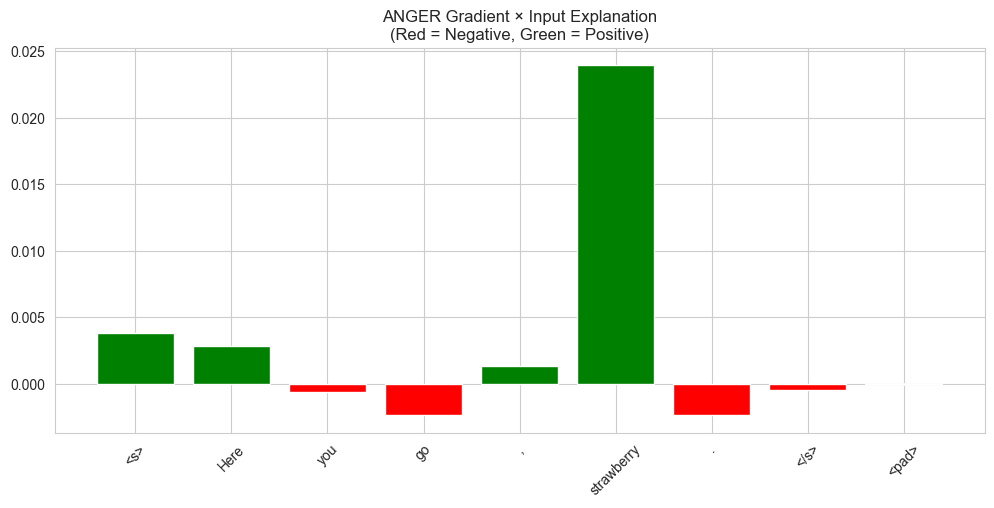

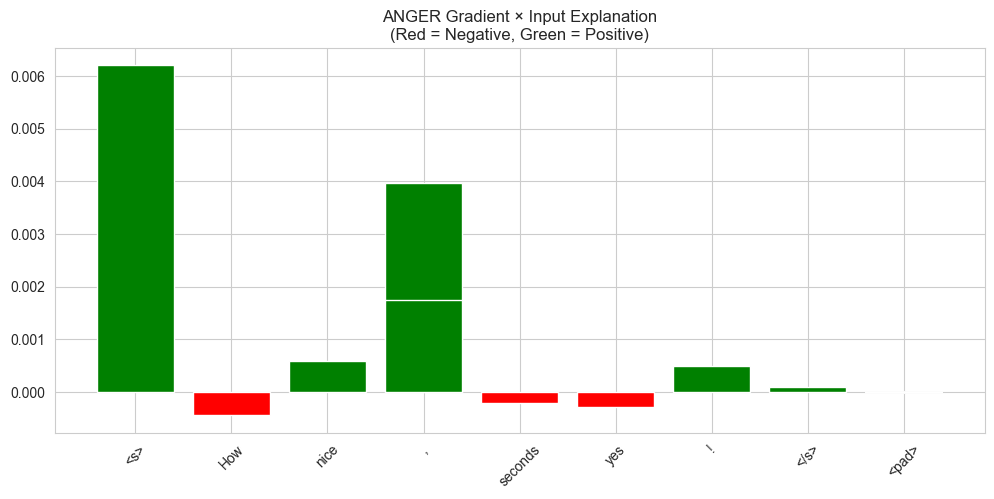

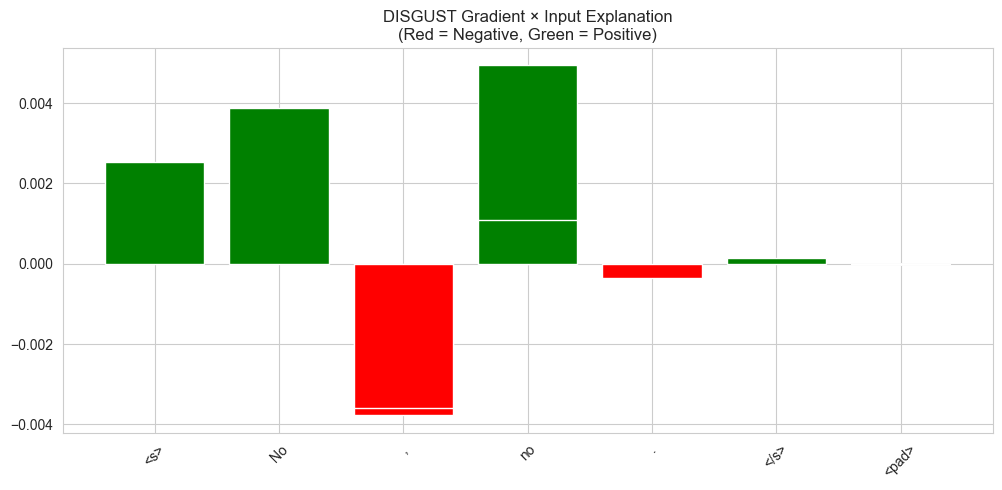

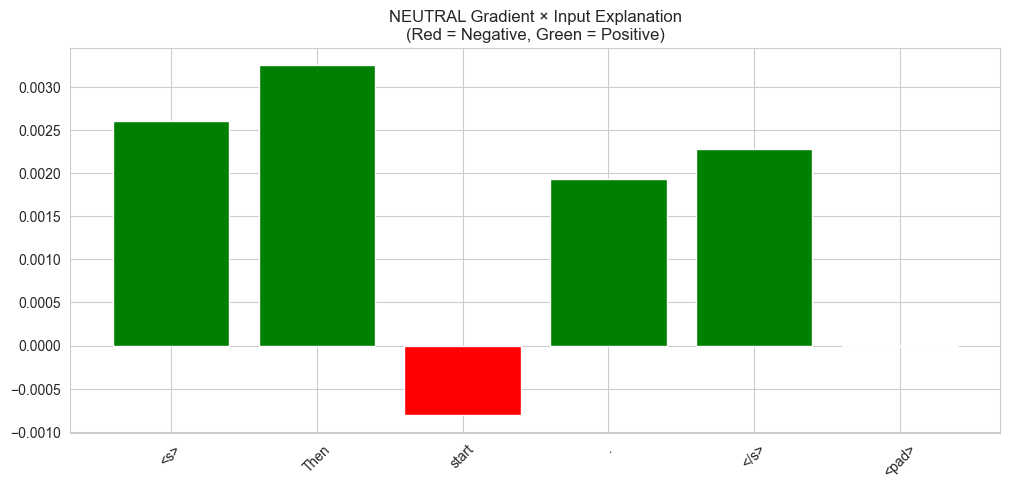

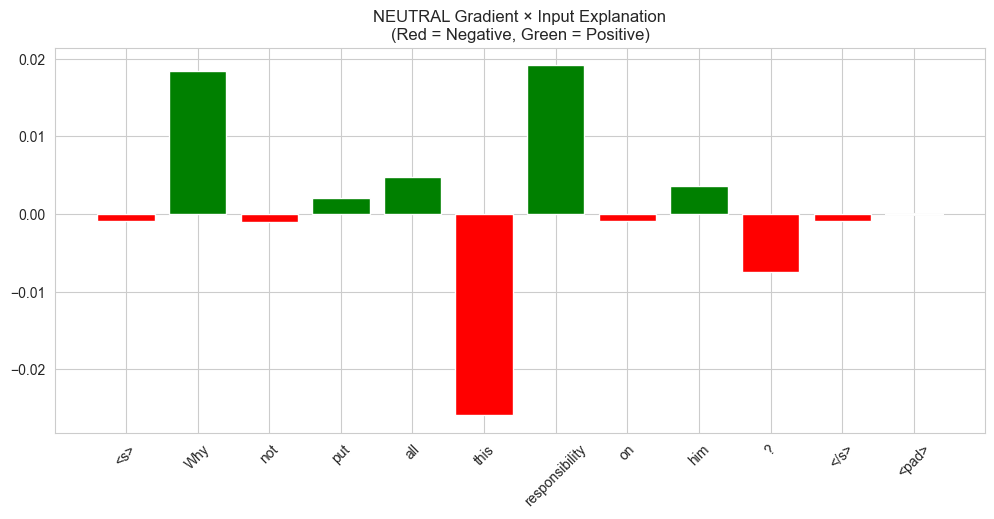

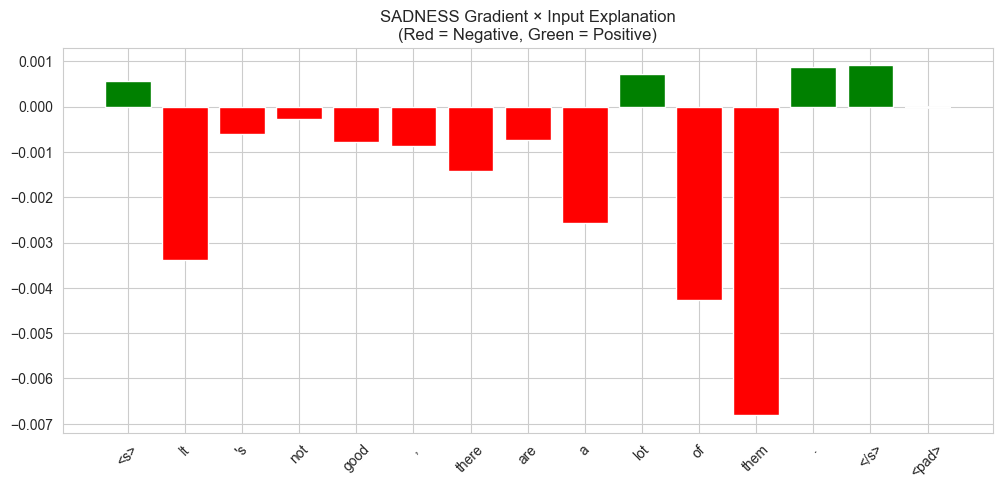

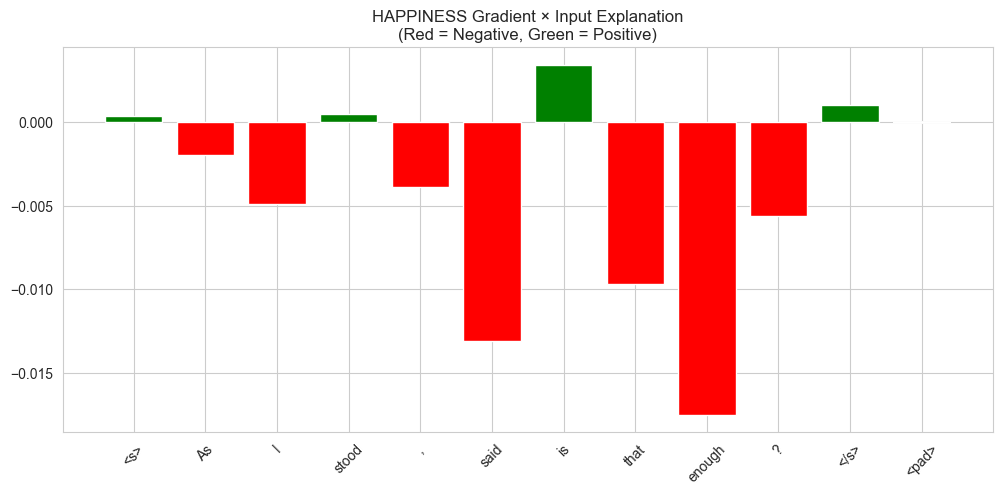

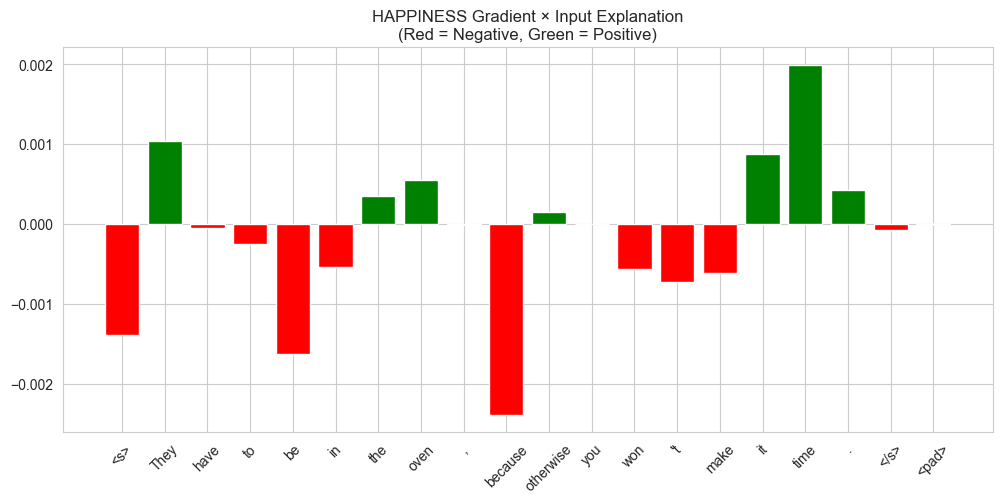

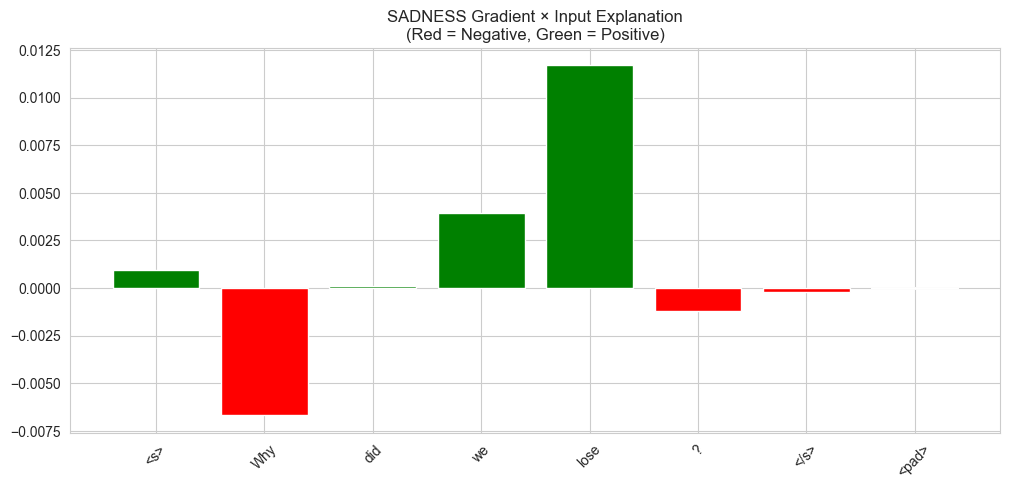

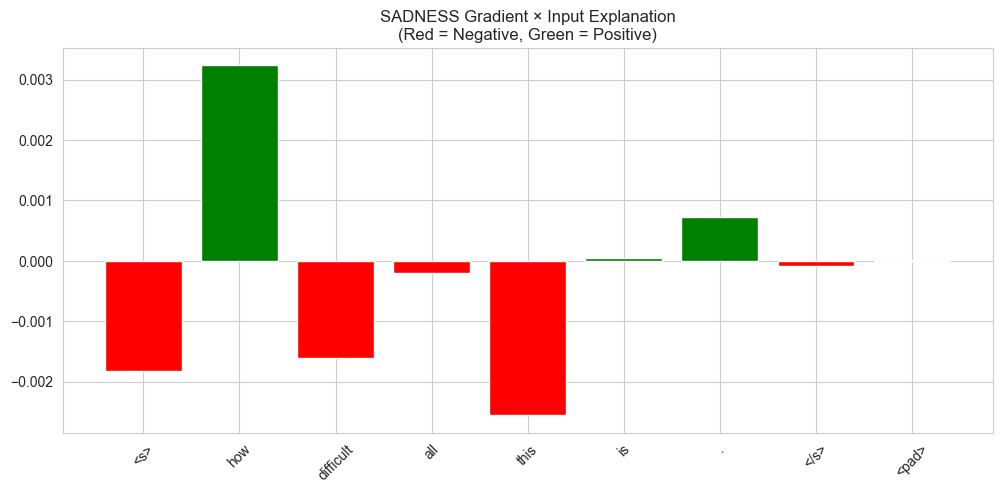

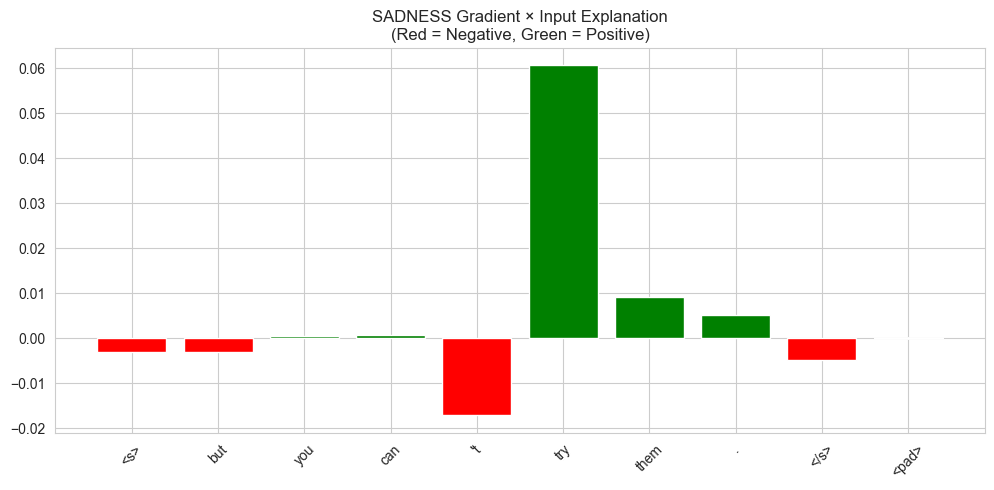

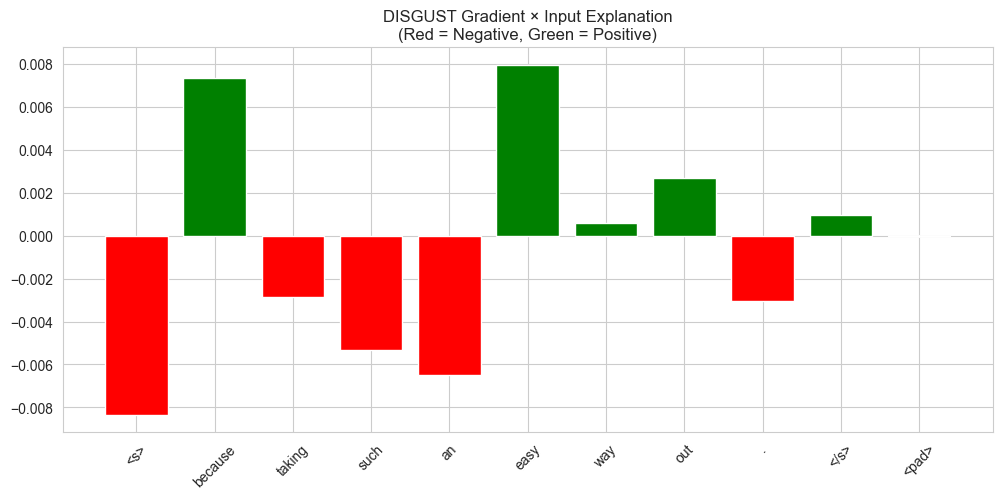

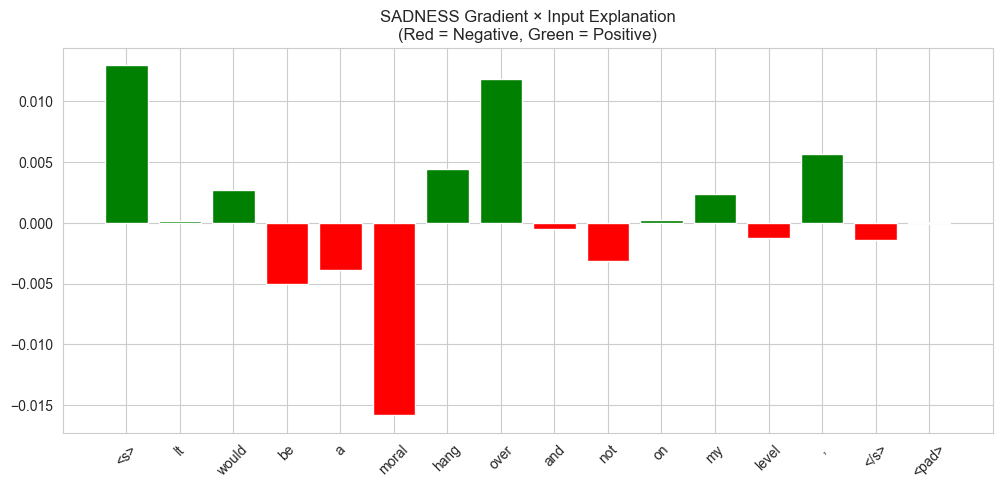

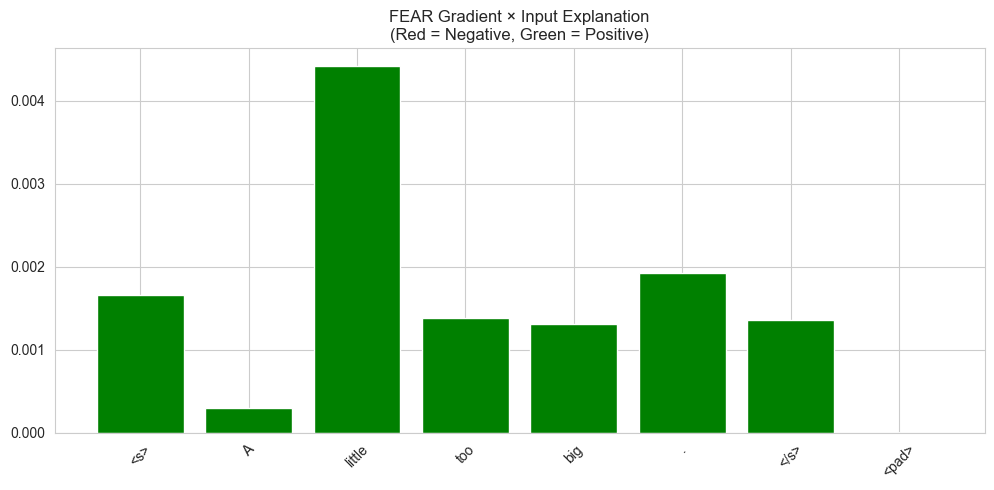

In [13]:
# Gradient × Input visualization for each sentence
for idx, sentence in enumerate(text):
    one_input = {k: v[idx].unsqueeze(0) for k, v in inputs.items()}
    from types import SimpleNamespace
    one_input_ns = SimpleNamespace(**one_input)
    relevance_scores = gradient_x_input(model, one_input_ns)
    tokens = [t.replace("Ġ", "") for t in tokenizer.convert_ids_to_tokens(one_input["input_ids"][0])]
    raw_scores = relevance_scores[0].detach().cpu().numpy()
    colors = ['red' if s < 0 else 'green' for s in raw_scores[:, 0]]
    label_str = model_label_to_emotion[predicted_emotion[idx]].upper()

    plt.figure(figsize=(12, 5))
    plt.bar(tokens, raw_scores[:, 0], color=colors)
    plt.title(f"{label_str} Gradient × Input Explanation\n(Red = Negative, Green = Positive)")
    plt.xticks(rotation=45)
    filename = f"gxi__{label_str}__ex{idx+1:02d}.png"
    plt.savefig(os.path.join(OUT_DIR, "gxi", filename), dpi=150)
    plt.show()


## Part 2

In [14]:
# --- Part 2: Conservative Propagation (LRP) — batch over your 6x3 examples ---

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from transformers import AutoTokenizer

# Use AutoTokenizer for your fine-tuned RoBERTa model
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True)



def to_device(batch, device):
    return {k: v.to(device) for k, v in batch.items()}

gxi_fn = getattr(lrp, "gradient_x_input", lrp.gradient_x_input)

def aggregate_subwords(tokens, scores, is_roberta_like=True):
    """
    Optional: collapse subword pieces into whole-word buckets for cleaner plots.
    For RoBERTa, new words are usually prefixed with 'Ġ'.
    Returns new_tokens, new_scores (length <= original).
    """
    if not is_roberta_like:
        return tokens, scores

    merged_tokens = []
    merged_scores = []
    cur_tok = ""
    cur_score = 0.0

    def flush():
        nonlocal cur_tok, cur_score
        if cur_tok != "":
            merged_tokens.append(cur_tok)
            merged_scores.append(cur_score)
            cur_tok, cur_score = "", 0.0

    for t, s in zip(tokens, scores):
        # Special tokens: keep as is
        if t in tokenizer.all_special_tokens:
            flush()
            merged_tokens.append(t)
            merged_scores.append(float(s))
            continue

        # RoBERTa new word marker
        if t.startswith("Ġ"):
            flush()
            cur_tok = t[1:]
            cur_score = float(s)
        else:
            # continuation of the same word
            if cur_tok == "":
                cur_tok = t
            else:
                cur_tok += t
            cur_score += float(s)

    flush()
    return merged_tokens, np.array(merged_scores, dtype=float)

def explain_sentence_with_gxi_and_lrp(model, tokenizer, text, device):
    """
    Returns:
      tokens, gxi_scalar_scores (per token), lrp_scalar_scores (per token),
      predicted_class_idx, predicted_class_label
    """
    enc = tokenizer(text, return_tensors="pt")
    enc = to_device(enc, device)

    # --- Gradient × Input ---
    gxi_tensor, tgt_idx = gxi_fn(model, enc)  # (1, T, d), int
    gxi_scores = gxi_tensor[0].detach().cpu().numpy().sum(axis=-1)  # (T,)

    # --- LRP-CP (last layer) ---
    lrp_scores, _ = lrp.lrp_cp_lastlayer_roberta(model, enc, target_idx=tgt_idx)
    lrp_scores = np.array(lrp_scores)  # (T,)

    # tokens and label
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    with torch.no_grad():
        out = model(**enc)
        pred_idx = int(out.logits.argmax(dim=-1).item())
    pred_label = id2label.get(pred_idx, str(pred_idx))

    return tokens, gxi_scores, lrp_scores, pred_idx, pred_label

def plot_and_save_bars(tokens, gxi_scores, lrp_scores, title, outpath,
                       merge_subwords=True):
    # Optional merge for readability
    if merge_subwords:
        tokens1, gxi1 = aggregate_subwords(tokens, gxi_scores, is_roberta_like=True)
        tokens2, lrp1 = aggregate_subwords(tokens, lrp_scores, is_roberta_like=True)
        if tokens1 != tokens2:
            tokens_plot, gxi_plot, lrp_plot = tokens, gxi_scores, lrp_scores
        else:
            tokens_plot, gxi_plot, lrp_plot = tokens1, gxi1, lrp1
    else:
        tokens_plot, gxi_plot, lrp_plot = tokens, gxi_scores, lrp_scores

    # Color bars by sign
    colors_gxi = ["red" if s < 0 else "green" for s in gxi_plot]
    colors_lrp = ["orange" if s < 0 else "blue" for s in lrp_plot]

    # Plot bars
    x = np.arange(len(tokens_plot))
    plt.figure(figsize=(max(12, len(tokens_plot)*0.55), 4.8))
    plt.bar(x - 0.2, gxi_plot, width=0.4, color=colors_gxi)
    plt.bar(x + 0.2, lrp_plot, width=0.4, color=colors_lrp)
    plt.axhline(0, linewidth=0.8, color="black")
    plt.xticks(x, tokens_plot, rotation=70)
    plt.title(title)

    # --- Custom legend with both colors per method ---
    legend_patches = [
        mpatches.Patch(color='green', label='Grad × Input (+)'),
        mpatches.Patch(color='red', label='Grad × Input (−)'),
        mpatches.Patch(color='blue', label='LRP-CP (+)'),
        mpatches.Patch(color='orange', label='LRP-CP (−)'),
    ]
    plt.legend(handles=legend_patches, loc='upper right')

    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    plt.close()

# ---- Run over your 6 x 3 examples and save figures ----
all_paths = []
for emotion, texts in examples_by_emotion.items():
    for i, text in enumerate(texts, 1):
        try:
            tokens, gxi_scores, lrp_scores, pred_idx, pred_lbl = explain_sentence_with_gxi_and_lrp(
                model, tokenizer, text, DEVICE
            )
            fig_title = f"{emotion} - example {i} - predicted={pred_lbl}"
            filename = f"{emotion}__{i:02d}__pred-{pred_lbl}.png".replace("/", "_")
            outpath = os.path.join(OUT_DIR, "lrp", filename)
            plot_and_save_bars(tokens, gxi_scores, lrp_scores, fig_title, outpath, merge_subwords=True)
            all_paths.append(outpath)
        except Exception as e:
            print(f"[WARN] Skipped one example for '{emotion}' (ex{i}): {e}")

print(f"Saved {len(all_paths)} explanation plots to: {OUT_DIR}")


Saved 21 explanation plots to: explanations_task_10_part_2


## Part 3

In [15]:
def get_model_confidence(model, input_ids, attention_mask, device):
    """
    Performs a forward pass and returns the model's confidence for the predicted class.

    Args:
        model (torch.nn.Module): The trained Transformer model.
        input_ids (torch.Tensor): The input token IDs.
        attention_mask (torch.Tensor): The attention mask.
        device (torch.device): The device to run the model on (e.g., 'cuda' or 'cpu').

    Returns:
        float: The confidence (probability) of the top predicted class.
    """
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=input_ids.to(device), attention_mask=attention_mask.to(device))
        logits = outputs.logits
        probabilities = F.softmax(logits, dim=-1)
        confidence, _ = torch.max(probabilities, dim=-1)
        return confidence.item()

def perform_perturbation_analysis(model, tokenizer, text, relevance_scores, device):
    """
    Performs input perturbation by removing the least relevant tokens and plots the results.

    Args:
        model (torch.nn.Module): The trained Transformer model.
        tokenizer: The tokenizer for the model.
        text (str): The input sentence.
        relevance_scores (np.array): The relevance scores from LRP for each token.
        device (torch.device): The device to run the model on.

    Returns:
        matplotlib.figure.Figure: The generated plot figure.
    """
    # 1. Tokenize the input text
    encoding = tokenizer(text, return_tensors='pt', truncation=True, padding='max_length', max_length=128)
    original_input_ids = encoding['input_ids']
    original_attention_mask = encoding['attention_mask']

    # Get the actual tokens (excluding special tokens like [CLS], [SEP], and [PAD])
    tokens = tokenizer.convert_ids_to_tokens(original_input_ids[0])

    # Filter out special tokens and their relevance scores for the analysis
    special_tokens = [tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token]
    valid_indices = [i for i, token in enumerate(tokens) if token not in special_tokens and i < len(relevance_scores)]

    # Ensure relevance_scores array is the correct size
    if len(relevance_scores) > len(tokens):
        relevance_scores = relevance_scores[:len(tokens)]

    # We only care about the relevance of actual words in the sentence
    filtered_relevance_scores = relevance_scores[valid_indices]

    # Get the indices of the least relevant tokens to remove, sorted from least to most relevant
    # We add the offset of the first valid index to map back to original indices
    sorted_relevance_indices = np.array(valid_indices)[np.argsort(filtered_relevance_scores)]

    # 2. Iteratively remove tokens and record model confidence
    confidence_scores = []

    # Start with the original sentence
    current_input_ids = original_input_ids.clone()
    current_attention_mask = original_attention_mask.clone()

    initial_confidence = get_model_confidence(model, current_input_ids, current_attention_mask, device)
    confidence_scores.append(initial_confidence)

    # Loop through the sorted indices of tokens to be removed
    for token_idx_to_remove in sorted_relevance_indices:
        # "Remove" the token by setting its attention mask to 0, so the model ignores it.
        # This is more efficient than creating new tensors each time.
        current_attention_mask[0, token_idx_to_remove] = 0

        # Get the new confidence score
        confidence = get_model_confidence(model, current_input_ids, current_attention_mask, device)
        confidence_scores.append(confidence)

    # 3. Generate the line graph
    fig, ax = plt.subplots(figsize=(10, 6))
    num_tokens_removed = range(len(confidence_scores))

    ax.plot(num_tokens_removed, confidence_scores, marker='o', linestyle='-')
    ax.set_title(f'Model Robustness for: "{text}"', wrap=True)
    ax.set_xlabel('Number of Least Relevant Tokens Removed')
    ax.set_ylabel("Model's Confidence in Prediction")
    ax.set_xticks(num_tokens_removed)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, 1.05)

    plt.tight_layout()
    return fig

[Errno 22] Invalid argument: 'explanations_task_10_part_2\\mr\\perturbation__surprise__Are_you_ready?_Reds?.png'
[Errno 22] Invalid argument: 'explanations_task_10_part_2\\mr\\perturbation__surprise__Shock,_right?.png'
[Errno 22] Invalid argument: 'explanations_task_10_part_2\\mr\\perturbation__sadness__Why_did_we_lose?.png'


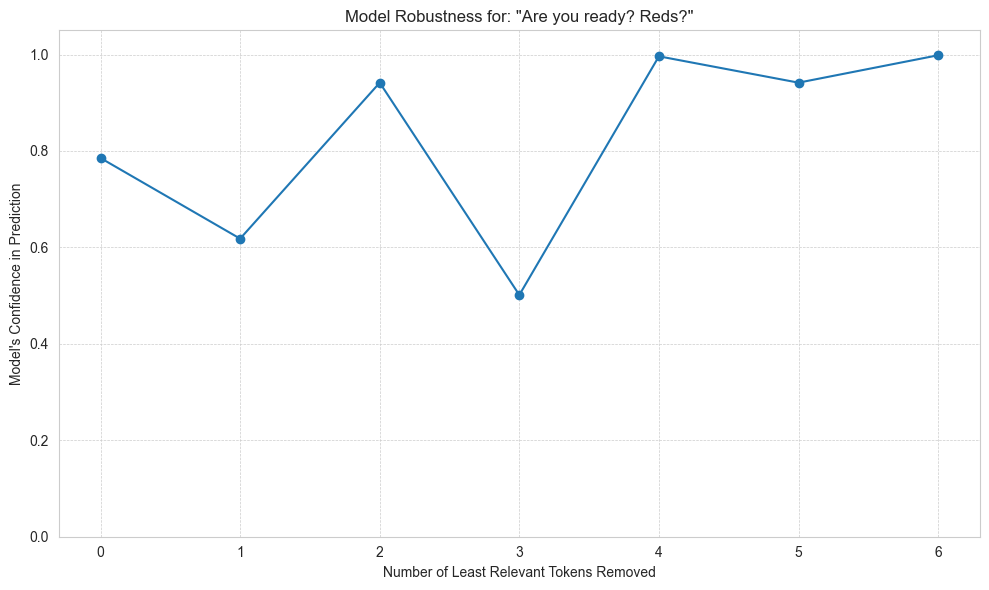

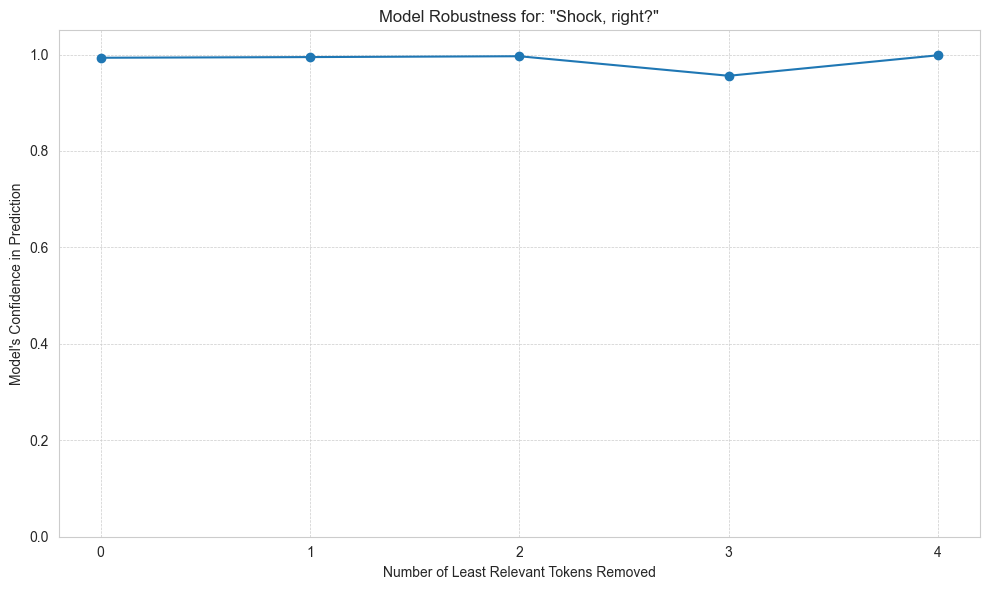

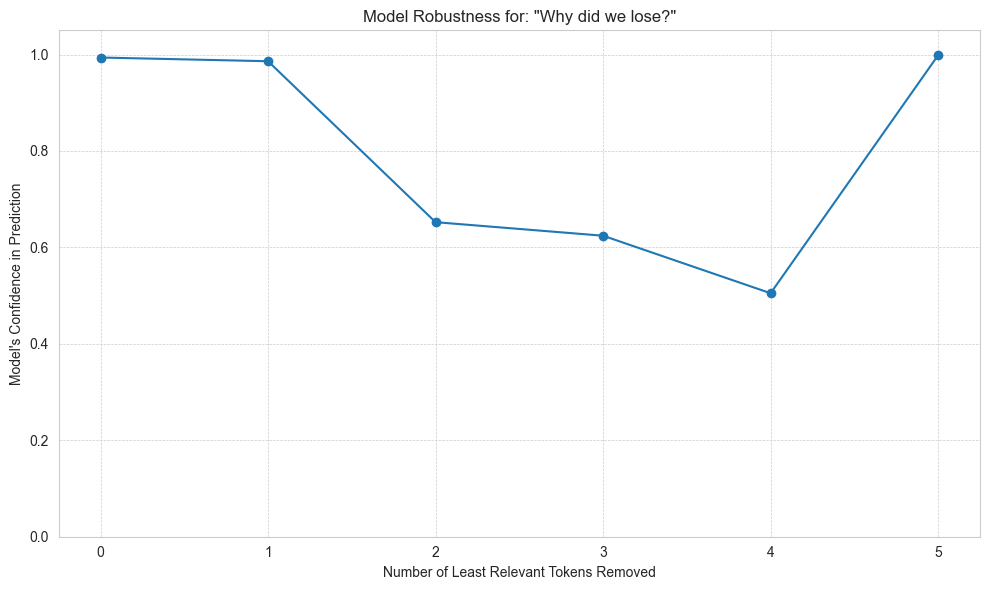

In [16]:
all_paths = []
for emotion, texts in examples_by_emotion.items():
    for i in texts:
        try:
            fig = perform_perturbation_analysis(model, tokenizer, i, lrp_scores, DEVICE)
            # save the figure
            filename = f"perturbation__{emotion}__{i[:30].replace(' ', '_')}.png"
            outpath = os.path.join(OUT_DIR, "mr", filename)
            fig.savefig(outpath, dpi=150)
            plt.close(fig)
            all_paths.append(outpath)
        except Exception as e:
            print(e)
